In [ ]:
### Please check _common.py for common paths and loaded packages 
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## Transfer function

In [2]:
### Read pre-computed spectra ###

sta_char = ['TA', '645A']
spec_data = np.load(os.path.join(data_dir, 'TA/spectrogram', f"{'_'.join(sta_char)}.npz"))

# Select time interval
_mask = (spec_data['timestamp'] >= UTCDateTime(2012,8,28,8,30).matplotlib_date) \
    & (spec_data['timestamp'] <= UTCDateTime(2012,8,29,11,30).matplotlib_date)      # TA.645A

# _mask = (spec_data['timestamp'] >= UTCDateTime(2012,8,28,19,30).matplotlib_date) \
#     & (spec_data['timestamp'] <= UTCDateTime(2012,8,29,22,30).matplotlib_date)      # TA.544A

### Calculate transfer function ###

# MI/SO analysis
psd = {'1': spec_data['psd_P'], '2': spec_data['psd_N'], '3': spec_data['psd_E'], 'o': spec_data['psd_Z']}
csd = {'1o': spec_data['csd_PZ'], '2o': spec_data['csd_NZ'], '3o': spec_data['csd_EZ'], 
       '12': spec_data['csd_PN'], '13': spec_data['csd_PE'], '23': spec_data['csd_NE']}
tf, pcoh = miso.miso_3input(psd, csd)

# Transfer function
Hpz = tf['1o']

In [3]:
### Statistics of observation ###

# Window size
win_size = 30
win_num = Hpz[:, _mask].shape[1] // win_size
Nlarge = Hpz.shape[0]

# Calculate median
_psd_Z = spec_data['psd_Z'][:, _mask][:, :win_num * win_size].reshape(Nlarge, win_num, win_size)
_psd_Z = np.median(_psd_Z, axis=2)
_Hpz = Hpz[:, _mask][:, :win_num * win_size].reshape(Nlarge, win_num, win_size)
_ph = np.rad2deg(np.arctan2(np.median(np.sin(np.angle(_Hpz)), axis=2),
                            np.median(np.cos(np.angle(_Hpz)), axis=2)))
_Hpz = np.median(np.abs(_Hpz), axis=2)
_coh = spec_data['coh_PZ'][:, _mask][:, :win_num * win_size].reshape(Nlarge, win_num, win_size)
_coh = np.median(_coh, axis=2)

# Coherence criterion
coh_mask = (_coh >= 0.8) & (1/spec_data['freqs'] < 200)[:, None]
_Hpz = np.ma.masked_array(_Hpz, mask=(~coh_mask))
_ph = np.ma.masked_array(_ph, mask=(~coh_mask))
_psd_Z = np.ma.masked_array(_psd_Z, mask=(~coh_mask))

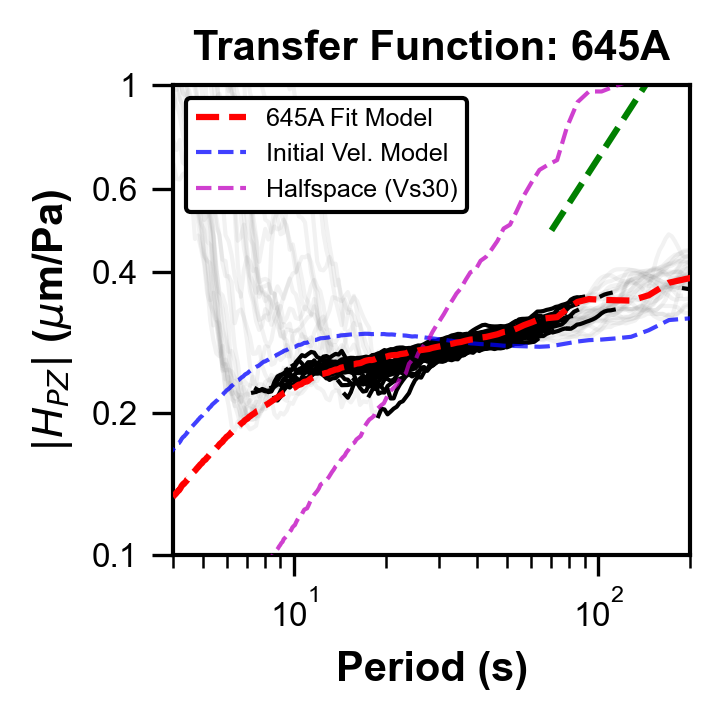

In [ ]:
### Read modeled transfer function ###
psd_les = np.load(os.path.join(data_dir, 'CM1/spectra', 'spectra_ref.npz'))
psd_les_init = np.load(os.path.join(data_dir, 'CM1/spectra', 'spectra_site.npz'))
psd_les_hs = np.load(os.path.join(data_dir, 'CM1/spectra', f'spectra_hs_{sta_char[1]}.npz'))

### Plot transfer function ###

fig, ax = plt.subplots(figsize=(2.5,2.5))
ax.loglog(1/spec_data['freqs'], _Hpz, '-', color='k', lw=1, alpha=1, zorder=2)
ax.loglog(1/spec_data['freqs'], np.ma.masked_where(~_Hpz.mask, _Hpz.data), '-', color='gray', lw=1, alpha=0.1, zorder=1)
ax.loglog(1/psd_les['freqs'], psd_les['tf_PZ'][0], 'r--', label='645A Fit Model', lw=1.5, zorder=4)
ax.loglog(1/psd_les_init['freqs'], psd_les_init['tf_PZ'][0], 'b--', label='Initial Vel. Model', lw=1, alpha=0.75, zorder=3)
ax.loglog(1/psd_les_hs['freqs'], psd_les_hs['tf_PZ'][0], 'm--', label='Halfspace (Vs30)', lw=1, alpha=0.75, zorder=3)
ax.set_xlabel('Period (s)')
ax.set_ylabel('$|H_{PZ}|$ ($\mu$m/Pa)')
ax.set_xlim(1/np.flip([5e-3, 0.25]))
ax.set_ylim(1e-1, 1e0)
ax.set_title(f'Transfer Function: {sta_char[1]}', fontsize=10)

y_ticks = [0.1, 0.2, 0.4, 0.6, 1]
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(tick) for tick in y_ticks])
# ax.set_yscale('linear')
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.legend(loc='upper left', prop={'size': 6})

f_ = np.linspace(1/200, 1/70, 100)
ax.plot(1/f_, 7e-3/f_, 'g--', lw=1.5)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, f'transfer_{sta_char[1]}.pdf'), dpi=400, bbox_inches='tight', pad_inches=0.01)

## MISO analysis

In [5]:
### Plotting time range ###
psd_tlim = [UTCDateTime(2012,8,27,0), UTCDateTime(2012,9,1,0)]

### Read wavelet spectra ###
sta_char = ['TA', '645A']
sta_loc = get_sta_loc(sta_char, pd.read_csv(os.path.join(data_dir, 'TA', 'TA_list.csv')))
spec_data = np.load(os.path.join(data_dir, 'TA/spectrogram', f"{'_'.join(sta_char)}.npz"))

### Station distance to TC ###
# Hurricane information: 2012 Isaac
tc_info = tc_func.get_tc_info(year=2012, name='Isaac', agency='USA')

# Interpolation function for TC track
f_loc, t0 = tc_func.get_interp_func(tc_info)

# Interpolate TC track
tc_timestamp, tc_lon, tc_lat = tc_func.interp_track(f_loc, t0, time_range=psd_tlim)

# Station distance to hurricane center [km]
tc_dist = tc_func.get_station_dist(sta_loc, np.array([tc_lon, tc_lat]))

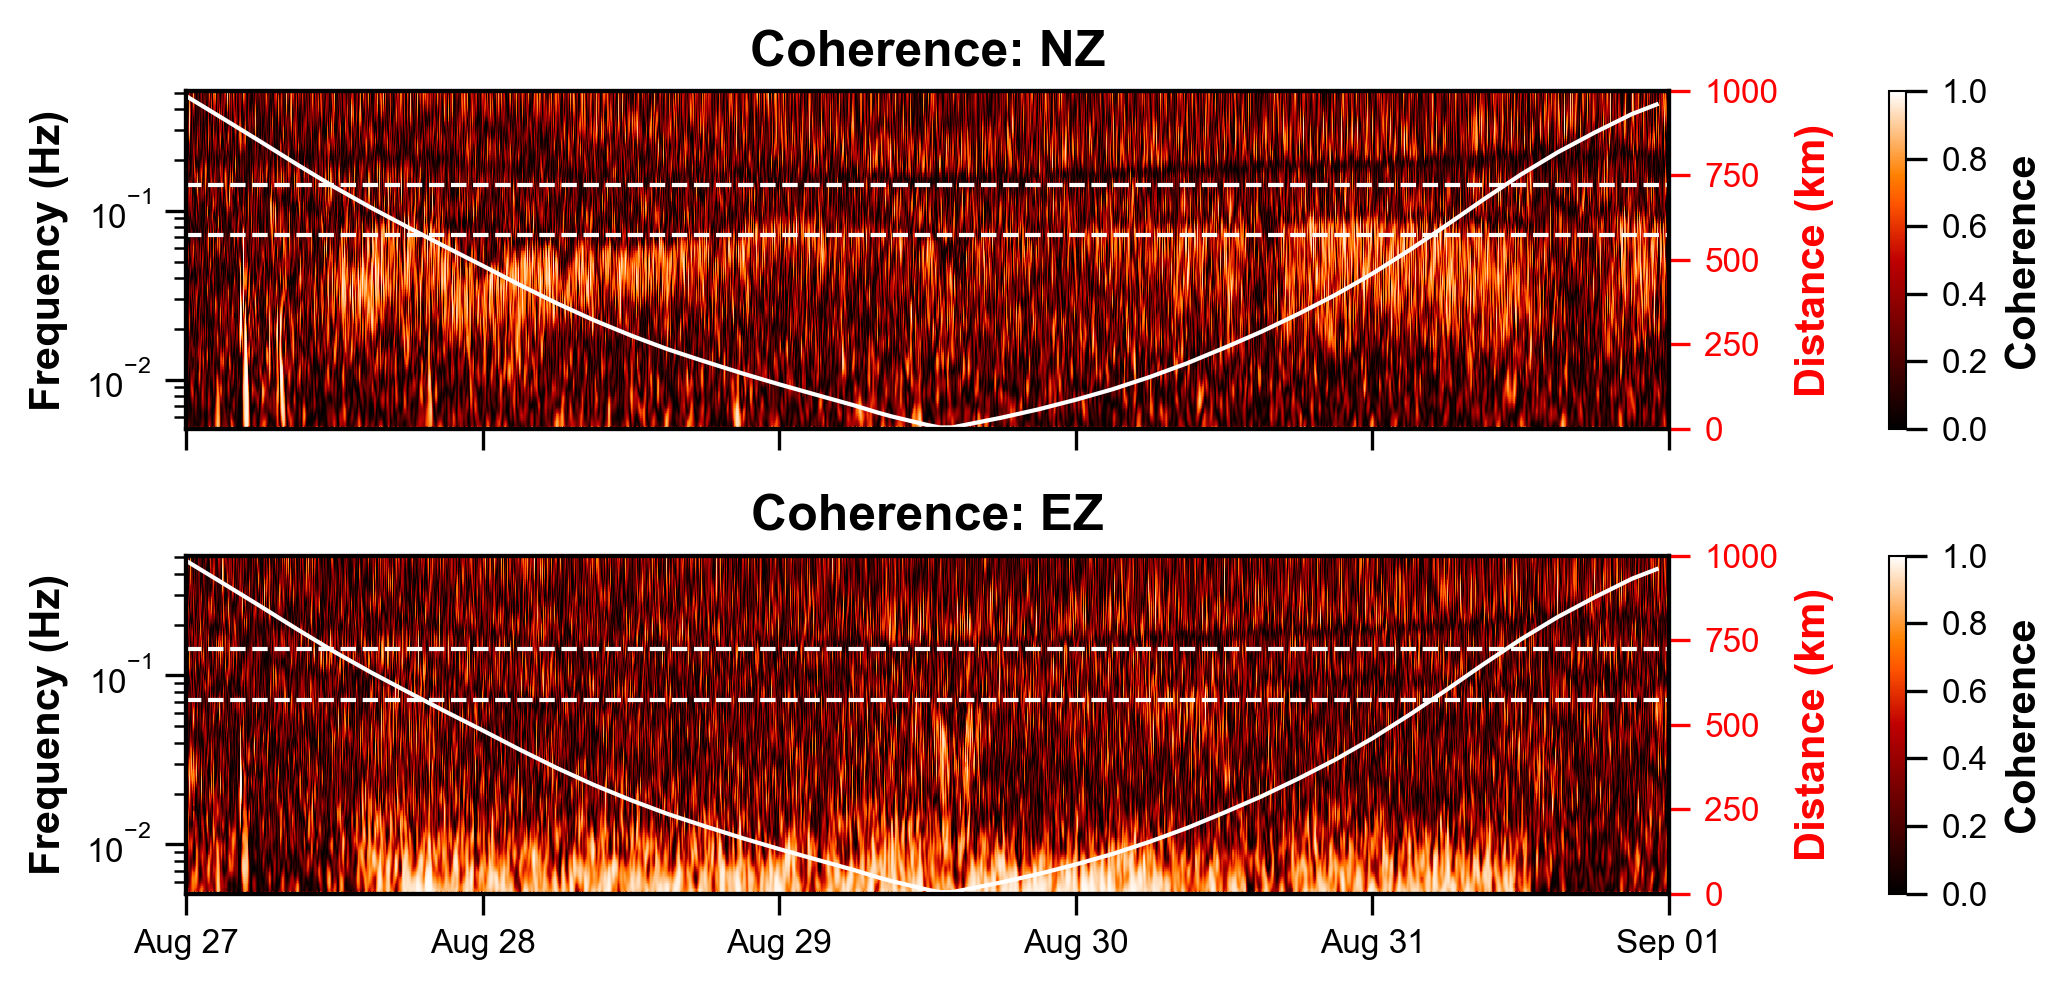

In [6]:
### Coherence ordering ###

### PZ coherence ###
fig, axes = plt.subplots(2, 1, figsize=(7.5, 3.4), sharex=True, sharey=True)

# Coherence: NZ
obj1 = pspec.plot_wt_coh(spec_data['timestamp'], spec_data['freqs'], spec_data['coh_NZ'], decimate=1,
                         cmap='gist_heat', freq_scale='log',
                         tc_time=tc_timestamp, tc_dist=tc_dist, dist_range=[0,1e3], ax=axes[0])

# Coherence: EZ
obj2 = pspec.plot_wt_coh(spec_data['timestamp'], spec_data['freqs'], spec_data['coh_EZ'], decimate=1, 
                         cmap='gist_heat', freq_scale='log',
                         tc_time=tc_timestamp, tc_dist=tc_dist, dist_range=[0,1e3], ax=axes[1])

axes[0].set_title('Coherence: NZ')
obj1[2].set_yticks([0, 250, 500, 750, 1000])

axes[1].set_xlim(psd_tlim[0], psd_tlim[1])
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%h %d'))
axes[1].set_title('Coherence: EZ')
obj2[2].set_yticks([0, 250, 500, 750, 1000])

for val in [1/7, 1/14]:
    axes[0].axhline(y=val, color='w', linestyle='--', linewidth=1)
    axes[1].axhline(y=val, color='w', linestyle='--', linewidth=1)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'coh_HZ.png'), dpi=400, bbox_inches='tight', pad_inches=0)

In [7]:
### Partial coherence & Transfer function ###

# Store coherence and transfer function
tf, coh = {}, {}

# Order: PNE -> Z
psd = {'1': spec_data['psd_P'], '2': spec_data['psd_N'], '3': spec_data['psd_E'], 'o': spec_data['psd_Z']}
csd = {'1o': spec_data['csd_PZ'], '2o': spec_data['csd_NZ'], '3o': spec_data['csd_EZ'],
       '12': spec_data['csd_PN'], '13': spec_data['csd_PE'], '23': spec_data['csd_NE']}
tf_, pcoh_ = miso.miso_3input(psd, csd)

tf['HPZ:1o'] = tf_['1o']
tf['LPZ:1o'] = tf_['L1o']
coh['P,Z-NE'] = np.abs(psd['1'] * tf_['1o'])**2 / psd['1'] \
    / (psd['1'] * np.abs(tf_['1o'])**2 + (1 - spec_data['coh_PZ'] - pcoh_['2o_1'] - pcoh_['3o_21']) * psd['o'])
coh['N-P,Z'] = pcoh_['2o_1']

# Order: PEN -> Z
psd = {'1': spec_data['psd_P'], '2': spec_data['psd_E'], '3': spec_data['psd_N'], 'o': spec_data['psd_Z']}
csd = {'1o': spec_data['csd_PZ'], '2o': spec_data['csd_EZ'], '3o': spec_data['csd_NZ'],
       '12': spec_data['csd_PE'], '13': spec_data['csd_PN'], '23': np.conj(spec_data['csd_NE'])}
tf_, pcoh_ = miso.miso_3input(psd, csd)

coh['E-P,Z'] = pcoh_['2o_1']

# Order: NPE -> Z
psd = {'1': spec_data['psd_N'], '2': spec_data['psd_P'], '3': spec_data['psd_E'], 'o': spec_data['psd_Z']}
csd = {'1o': spec_data['csd_NZ'], '2o': spec_data['csd_PZ'], '3o': spec_data['csd_EZ'],
       '12': np.conj(spec_data['csd_PN']), '13': spec_data['csd_NE'], '23': spec_data['csd_PE']}
tf_, pcoh_ = miso.miso_3input(psd, csd)

tf['HPZ:2o'] = tf_['2o']
tf['LPZ:2o'] = tf_['L2o']
coh['P-N,Z'] = pcoh_['2o_1']

# Order: NEP -> Z
psd = {'1': spec_data['psd_N'], '2': spec_data['psd_E'], '3': spec_data['psd_P'], 'o': spec_data['psd_Z']}
csd = {'1o': spec_data['csd_NZ'], '2o': spec_data['csd_EZ'], '3o': spec_data['csd_PZ'],
       '12': spec_data['csd_NE'], '13': np.conj(spec_data['csd_PN']), '23': np.conj(spec_data['csd_PE'])}
tf_, pcoh_ = miso.miso_3input(psd, csd)

tf['HPZ:3o'] = tf_['3o']
coh['P-NE,Z'] = pcoh_['3o_21']

In [8]:
### Analysis on modeling time ###

# LES modeling time
les_tlim = [UTCDateTime(2012,8,28,23,30), UTCDateTime(2012,8,29,0,30)]
les_tlim = [obj.matplotlib_date for obj in les_tlim]
les_tmask = (spec_data['timestamp'] >= les_tlim[0]) & (spec_data['timestamp'] <= les_tlim[1])

# Statistics of spectral results
stat_coh = {}
for key in coh.keys():
    stat_coh[key] = np.mean(coh[key][:, les_tmask], axis=1)

for key in ['coh_PN', 'coh_PE', 'coh_PZ', 'coh_NZ', 'coh_EZ']:
    stat_coh[key] = np.mean(spec_data[key][:, les_tmask], axis=1)

stat_tf = {}
for key in tf.keys():
    stat_tf[key] = np.mean(np.abs(tf[key])[:, les_tmask], axis=1)

stat_ph = {}
for key in tf.keys():
    stat_ph[key] = np.rad2deg(np.arctan2(np.mean(np.sin(np.angle(tf[key]))[:, les_tmask], axis=1),
                                         np.mean(np.cos(np.angle(tf[key]))[:, les_tmask], axis=1)))

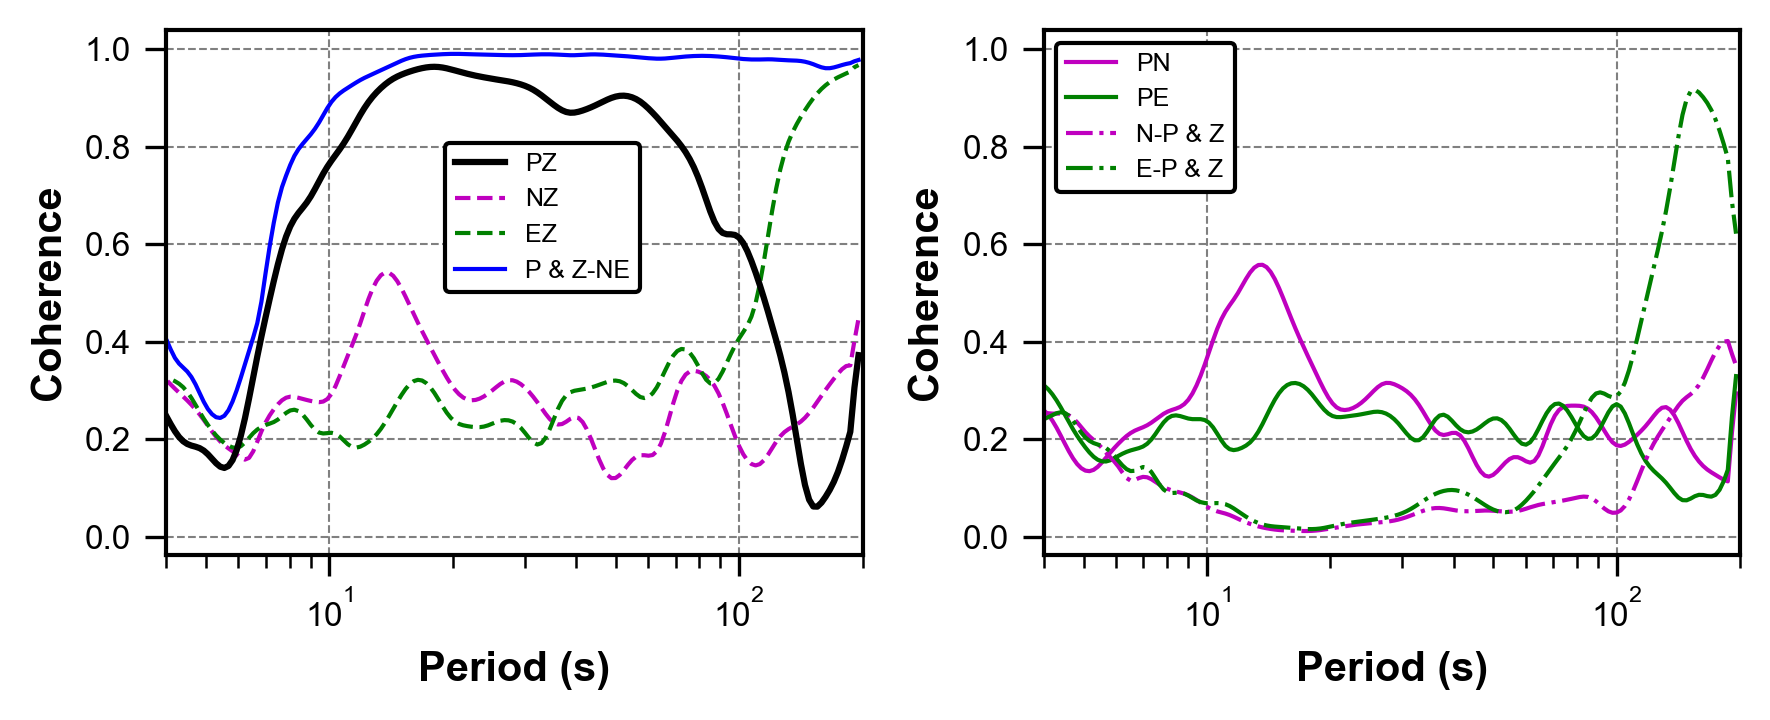

In [9]:
### Plot coherence ###

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharex=True, sharey=True)
axes[0].plot(1/spec_data['freqs'], stat_coh['coh_PZ'], 'k-', label='PZ', lw=1.5, zorder=10)
axes[0].plot(1/spec_data['freqs'], stat_coh['coh_NZ'], 'm--', label='NZ')
axes[0].plot(1/spec_data['freqs'], stat_coh['coh_EZ'], 'g--', label='EZ')
axes[0].plot(1/spec_data['freqs'], stat_coh['P,Z-NE'], 'b-', label='P & Z-NE')
axes[0].set_xscale('log')
axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel('Coherence')
axes[0].set_xlim(1/np.flip([5e-3, 0.25]))
axes[0].legend(prop={'size': 6}, loc=[0.4, 0.5])
axes[0].grid()

axes[1].plot(1/spec_data['freqs'], stat_coh['coh_PN'], 'm-', label='PN')
axes[1].plot(1/spec_data['freqs'], stat_coh['coh_PE'], 'g-', label='PE')
axes[1].plot(1/spec_data['freqs'], stat_coh['N-P,Z'], 'm-.', label='N-P & Z')
axes[1].plot(1/spec_data['freqs'], stat_coh['E-P,Z'], 'g-.', label='E-P & Z')
axes[1].set_xlabel('Period (s)')
axes[1].set_ylabel('Coherence')
axes[1].tick_params(labelleft=True)
axes[1].grid()
axes[1].legend(prop={'size': 6})

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'par_coh.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)


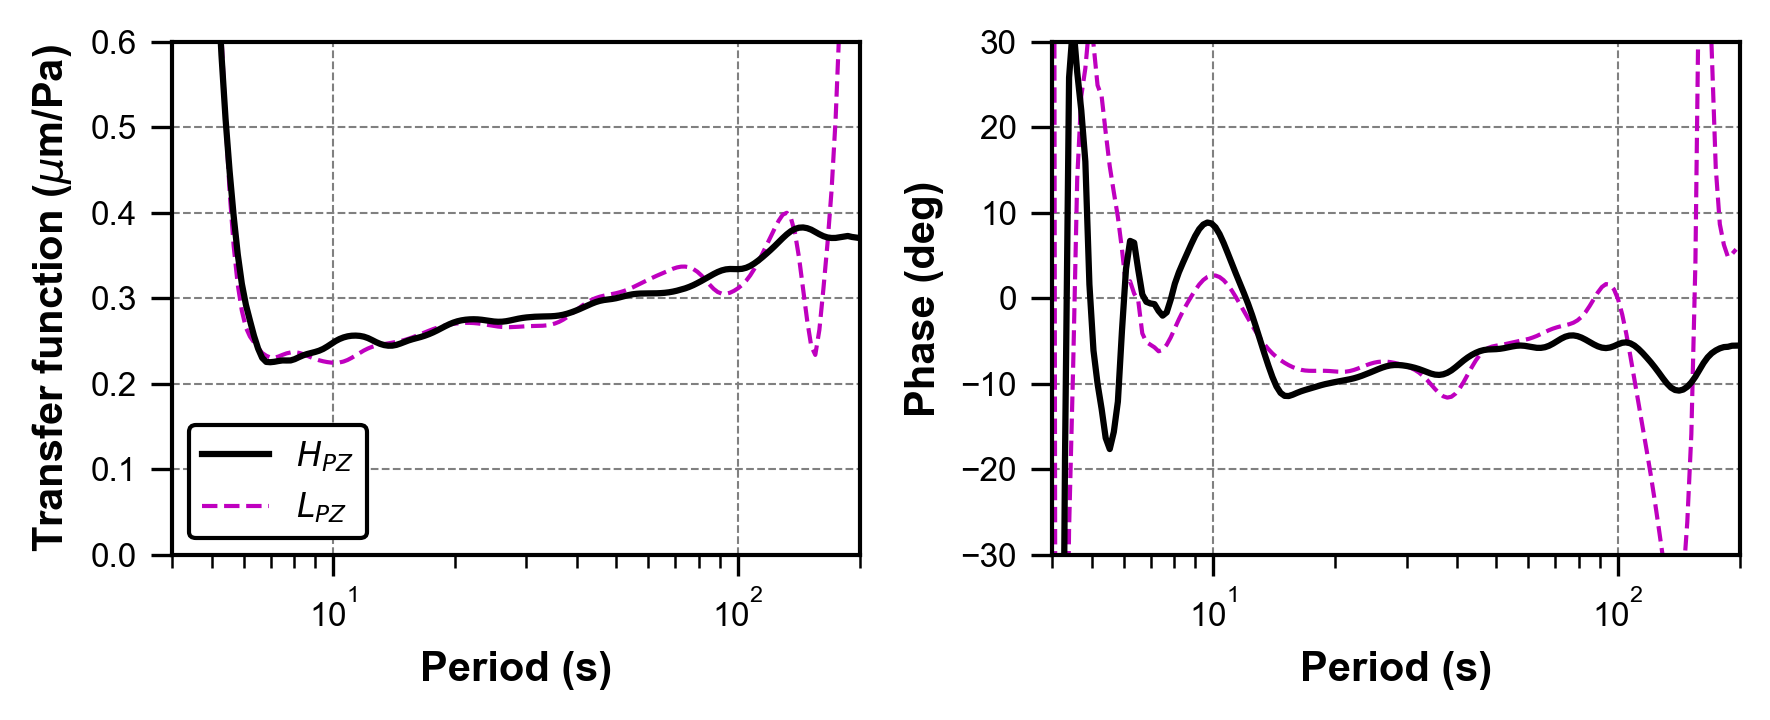

In [10]:
### Plot transfer function ###

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharex=True)
axes[0].plot(1/spec_data['freqs'], stat_tf['HPZ:1o'], 'k-', label='$H_{PZ}$', lw=1.5, zorder=10)
axes[0].plot(1/spec_data['freqs'], stat_tf['LPZ:1o'], 'm--', label='$L_{PZ}$')
axes[0].set_xscale('log')
axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel('Transfer function ($\mu$m/Pa)')
axes[0].set_xlim(1/np.flip([5e-3, 0.25]))
axes[0].set_ylim([0, 0.6])
axes[0].legend(prop={'size': 8})
axes[0].grid()

axes[1].plot(1/spec_data['freqs'], stat_ph['HPZ:1o'], 'k-', label='$H_{PZ}$', lw=1.5, zorder=10)
axes[1].plot(1/spec_data['freqs'], stat_ph['LPZ:1o'], 'm--', label='$L_{PZ}$')
axes[1].set_xlabel('Period (s)')
axes[1].set_ylabel('Phase (deg)')
axes[1].set_ylim([-30, 30])
axes[1].grid()

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'tf_phase.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Influence of convection velocity

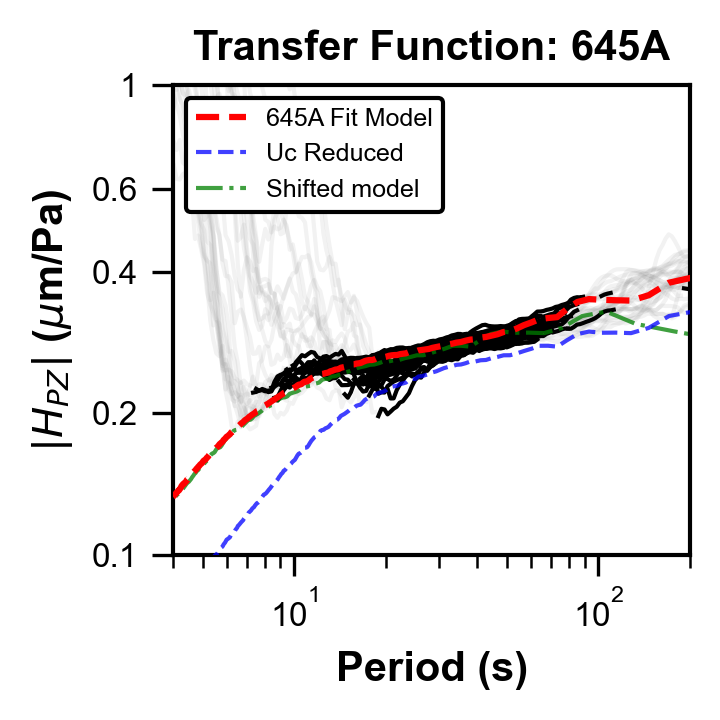

In [11]:
### Read modeled transfer function ###
psd_les = np.load(os.path.join(data_dir, 'CM1/spectra', 'spectra_ref.npz'))
psd_les_reduce = np.load(os.path.join(data_dir, 'CM1/spectra', 'spectra_ref_reduce_Uc.npz'))

### Plot transfer function ###

fig, ax = plt.subplots(figsize=(2.5,2.5))
ax.loglog(1/spec_data['freqs'], _Hpz, '-', color='k', lw=1, alpha=1, zorder=2)
ax.loglog(1/spec_data['freqs'], np.ma.masked_where(~_Hpz.mask, _Hpz.data), '-', color='gray', lw=1, alpha=0.1, zorder=1)
ax.loglog(1/psd_les['freqs'], psd_les['tf_PZ'][0], 'r--', label='645A Fit Model', lw=1.5, zorder=4)
ax.loglog(1/psd_les_reduce['freqs'], psd_les_reduce['tf_PZ'][0], 'b--', label='Uc Reduced', lw=1, alpha=0.75, zorder=3)
ax.loglog(1/psd_les_reduce['freqs'] / (25.09/13), psd_les_reduce['tf_PZ'][0], 'g-.', label='Shifted model', lw=1, alpha=0.75, zorder=2)
ax.set_xlabel('Period (s)')
ax.set_ylabel('$|H_{PZ}|$ ($\mu$m/Pa)')
ax.set_xlim(1/np.flip([5e-3, 0.25]))
ax.set_ylim(1e-1, 1e0)
ax.set_title(f'Transfer Function: {sta_char[1]}', fontsize=10)

y_ticks = [0.1, 0.2, 0.4, 0.6, 1]
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(tick) for tick in y_ticks])
# ax.set_yscale('linear')
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.legend(loc='upper left', prop={'size': 6})

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, f'transfer_{sta_char[1]}.pdf'), dpi=400, bbox_inches='tight', pad_inches=0.01)